## Esercizio A

Data la matrice
$$
\left[
\begin{array}{cccc}
4.5 & 1 & 3 & 2\\
1 & -8 & 2 & 1\\
-1 & -2 & -3 & -1\\
2 & 6 & 0 & 1
\end{array}
\right ],
$$

calcolarne la fattorizzazione lu di Gauss  facendo uso della funzione scipy.linalg.lu  e sfruttarla per il calcolo del suo determinante e della sua inversa.

In [44]:
import numpy.linalg as lin
import numpy as np
import scipy.linalg as splin
from SolveTriangular import *

A = np.array([[4.5, 1, 3, 2], [1, -8, 2, 1], [-1, -2, -3, -1], [2, 6, 0, 1]])

s = lambda PT: (len(PT) - np.count_nonzero(np.diag(PT))) / 2
def det(A):
    PT, L, U = splin.lu(A)
    return np.prod(np.diag(U)) * (-1)**(s(PT))
    
print(f'determinamente ø {det(A)}')

def solveLU(A, b):
    PT, L, U = splin.lu(A)
    x = Usolve(U, Lsolve(L, PT.T @ b))
    return x

def inverso(A):
    B = np.identity(len(A))
    return np.array([solveLU(A, B[:, i]) for i, v in enumerate(A[0,:])]).T

print(f'Inverso → \n{inverso(A)}')

determinamente ø 58.00000000000001
Inverso → 
[[ 0.5862069  -0.36206897  0.34482759 -0.46551724]
 [-0.01724138 -0.07758621 -0.06896552  0.04310345]
 [ 0.17241379 -0.22413793 -0.31034483 -0.43103448]
 [-1.06896552  1.18965517 -0.27586207  1.67241379]]


## Esercizio  B

Siano assegnati i punti del piano di coordinate $(x_i, y_i)$, $i=1,\ldots,4$ con 
$$
\begin{array}{c}
x_1=0, \quad x_2=4, \quad x_3=0, \quad x_4=5\\
y_1=0, \quad y_2=0, \quad y_3=4, \quad y_4=6.
\end{array}
$$ 
Scrivere lo script Python  in cui
- si costruisca il sistema lineare sovradeterminato ottenuto imponendo il passaggio della circonferenza di equazione $x^2+y^2+a_1x+a_2y+a_3=0$ per i quattro punti assegnati, e si denotino con ${\bf A}$ e ${\bf b}$ la matrice dei coefficienti e il termine noto ottenuti;   [**punti 2**]

- si sfrutti la decomposizione QR  della matrice A  per ottenere la soluzione ${\bf a}^*$ del problema ai minimi quadrati $\min_{{\bf a} \in \mathbb{R}^3} \|{\bf A}{\bf a}-{\bf b}\|_2^2$  e  si calcoli il valore di $\|{\bf A}{\bf a}^*-{\bf b}\|_2^2$;   [**punti 5**]

-  dopo averne determinato centro e raggio, si rappresentino in una stessa figura la circonferenza di equazione $x^2+y^2+a^*_1x+a^*_2y+a^*_3=0$ (individuata dalla soluzione ${\bf a}^*$ del problema ai minimi quadrati) e i quattro punti assegnati dal problema.[**punti 3**]


**Nota Bene**: Si ricorda che data una circonferenza nella forma canonica
$$ x^2+y^2+a_1 x+a_2 x+a_3=0$$

le coordinate del suo centro sono 
$$C≡(-a_1/2,-a_2/2)$$

e la lunghezza del suo raggio è data da:

$$r=\sqrt{\frac{a_1^2}{4}+\frac{a_2^2}{4} -a_3}$$

e la circoferenza può essere rappresentata in forma parametrica $C(t),  t \in [0, 2 \cdot \pi]$ e le due componenti parametriche sono $$x(t)= C_0+r\cdot cos(t);$$ $$ y(t)= C_1+r\cdot sin(t)$$

Condizionamento di A → 7.077139955161009
Residuo → 36.6984126984127


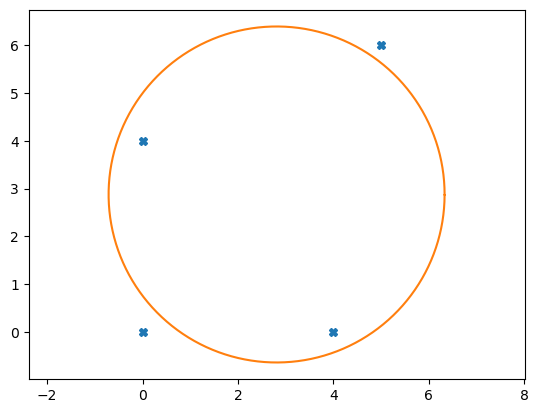

In [90]:
import matplotlib.pyplot as plt
from numpy.linalg import matrix_rank as rank

x= np.array([ 0, 4, 0, 5])
y= np.array([0, 0, 4, 6])

A = np.ones((len(x), 3))
A[:,1] = y
A[:,2] = x
b = -(x**2 + y**2)

print(f'Condizionamento di A → {lin.cond(A)}')
#Molto basso, usiamo eqnorm

def eqnorm(A, b):
    G = A.T @ A
    print(f'Condizionamento di G → {lin.cond(G)}')
    L = lin.cholesky(G)
    
    return Usolve(L.T, Lsolve(L, A.T @ b))

def qrLS(A, b):
    Q, R = splin.qr(A)
    h = Q.T @ b
    return Usolve(R[:rank(A)], h[:rank(A)])

ls = qrLS

a_star = np.flip(ls(A, b))
residuo = lin.norm(A @ np.flip(a_star) - b, 2)**2
print(f'Residuo → {(residuo)}')

C = lambda a, b, c: (-a/2, -b/2)
r = lambda a, b, c: np.sqrt(a**2/4+b**2/4-c)
raggio = r(*a_star)

t = np.arange(0, 2*np.pi, 0.01)
xt = C(*a_star)[0] + raggio * np.cos(t)
yt = C(*a_star)[1] + raggio * np.sin(t)

plt.plot(x, y, 'X')
plt.plot(xt, yt)
plt.axis('equal')
plt.show()

## Esercizio C
Per i dati $(x_i, y_i)$ riportati nei seguenti array

x = np.array([0.0004, 0.2507, 0.5008, 2.0007, 8.0013]) 

y = np.array([0.0007,0.0162, 0.0288, 0.0309, 0.0310])

- costruire la retta di regressione;
- costruire la parabola approssimante i dati nel senso dei minimi quadrati;
- determinare l'approssimazione ai minimi quadrati espressa in termini di
basi esponenziali: $y = a + b e^{-x}+ c e^{-2x}$

Quale tra le tre approssimazioni risulta la migliore? (Confrontare i grafici e la norma euclidea al quadrato del vettore dei residui).


Condizionamento di A (retta): 4.663457775986457
Condizionamento di G (): 21.747838428408542

Residuo A (retta): 0.0004848327762313227

Condizionamento di A (parabola): 65.67493525624792

Residuo A (parabola): 0.00023646355940249846

Condizionamento di A (base esponeziale): 18.45808953019451
Condizionamento di G (): 340.70106910467723

Residuo A (base esponeziale): 1.2249733128901812e-05


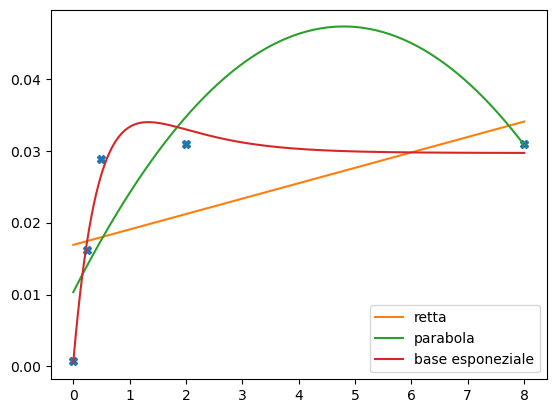

In [119]:
x = np.array([0.0004, 0.2507, 0.5008, 2.0007, 8.0013]) 
y = np.array([0.0007,0.0162, 0.0288, 0.0309, 0.0310])

residuo = lambda A, a_star, b: lin.norm(A @ a_star - b, 2)**2

def eqnorm(A, b):
    G = A.T @ A
    L = lin.cholesky(G)
    print(f'Condizionamento di G (): {lin.cond(G)}')
    return Usolve(L.T, Lsolve(L, A.T @ b))

def qrLS(A, b):
    Q, R = splin.qr(A)
    h = Q.T @ b
    return Usolve(R[:rank(A)], h[:rank(A)])

def plot_regression_vander(x, y, method, name, n):
    xv = np.linspace(min(x), max(x), 200)
    A = np.vander(x, increasing=True)[:,:n+1]
    print(f'\nCondizionamento di A ({name}): {lin.cond(A)}')
    reg = method(A, y)
    print(f'\nResiduo A ({name}): {residuo(A, reg, y)}')
    plt.plot(xv, np.polyval(np.flip(reg), xv), label=name)
    plt.legend()

def plot_regression_func(x, y, method, name, func, A):
    xv = np.linspace(min(x), max(x), 200)
    print(f'\nCondizionamento di A ({name}): {lin.cond(A)}')
    reg = method(A, y)
    print(f'\nResiduo A ({name}): {residuo(A, reg, y)}')
    plt.plot(xv, func(xv, *reg), label=name)
    plt.legend()

#Retta di regressione
plt.plot(x, y, 'X')
plot_regression_vander(x, y, eqnorm, 'retta', 1)
plot_regression_vander(x, y, qrLS, 'parabola', 2)
func = lambda x, a, b, c: a + b*np.exp(-x) + c*np.exp(-2*x) 
A = np.ones((len(x), 3))
A[:,1] = np.exp(-x)
A[:,2] = np.exp(-2*x)
plot_regression_func(x, y, eqnorm, 'base esponeziale', func, A)

# Esercizio D

La temperatura T in prossimita' del suolo varia al variare della concentrazione k dell'acido carbonico e della latitudine L. Per k=1.5 la temperatura al suolo subisce una variazione dipendente dalla temperatura secondo la seguente tabella 

L	[-55	-45	-35	-25	-15	-5	5	15	25	35	45	55	65]

T	[3.7	3.7	3.52	3.27	3.2	3.15	3.15	3.25	3.47	3.52	3.65	3.67	3.52]

Si vuole costruire un MODELLO che descriva la legge T=T(L) anche per latitudini non misurate. 
Ad esempio si vuole valutare la variazione di temperatura a Londra ( L=51°).
mediante interpolazione con un polinomio di grado 12.
Valutare e disegnare, inoltre, il polinomio interpolatore di Lagrange in un set di 100 dati equidistanti nell’intervallo min(L), max(L).
Descrivere i risultati alla luce della teoria.

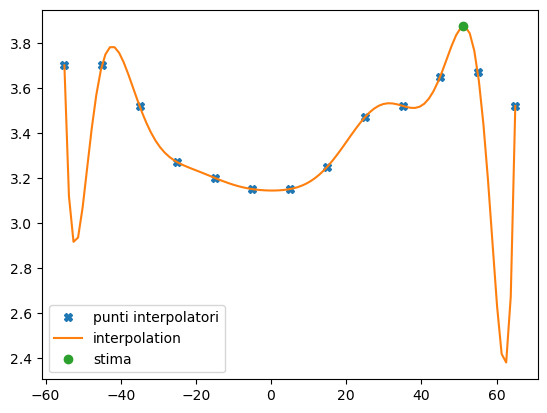

In [134]:

L=np.array([-55,-45,-35,-25,-15,-5,5,15,25,35,45,55,65])
T=np.array([3.7,3.7,3.52,3.27,3.2,3.15,3.15,3.25,3.47,3.52,3.65,3.67,3.52])

def lagrange(xnodi, val_j):
    x = xnodi[xnodi != val_j]
    num = np.poly(x)
    den = np.polyval(num, val_j)
    return num/den

def interL(x, y, xv):
    L = np.array([np.polyval(lagrange(x, v), xv) for v in x])
    return L.T @ y

def plot_interpolation(x, y):
    xv = np.linspace(min(x), max(x), 100)
    plt.plot(xv, interL(x, y, xv), label='interpolation')
    plt.legend()

def plot_scatter(x, y, x_stima):
    plt.plot(x_stima, interL(x, y, [x_stima]), 'o', label='stima')
    plt.legend()

plt.plot(L, T, 'X', label='punti interpolatori')
plot_interpolation(L, T)
plot_scatter(L, T, 51)

## Esercizio E

-  Implementare il  metodo di Newton Raphson, la variante delle corde e la variante di Shamanskii per la soluzione di un sistema non lineare

Risolvere il sistema di equazioni non lineare 

$$
\left[
\begin{array}{c}
x_0^2+x_0x_1=10 \\
 x_1+3x_0x_1^2=57
\end{array}
\right.
$$
con ciascuno dei tre metodi e confrontare per ciascun metodo il grafico dell'errore relativo tra due iterati successivi, giustificando i risultati alla luce della teoria.

- Descrivi la variante del Metodod di Newton-Raphson per calcolare il minimo di una funzione non lineare in più variabili

 

**Nota Bene**: Servirsi del metodo grafico per individuare un 
iterato iniziale  $X_0$ nell'intorno della soluzione che si vuole approssimare. Visualizzare le 
curve di livello corrisponenti a z=O delle due superfici z = f1 (x1 ,x2 ) e z = f2(x1 , x 2 ) e 
definire come iterato iniziale un vettore $X_0$ oppurtuno le cui componenti stanno in un 
intorno della soluzione (punti di intersezione tra le curve di livello delle due superfici) \]

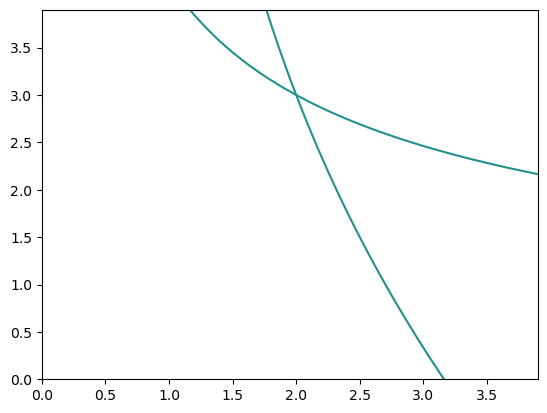

soluzioni → [2. 3.]
soluzioni → [2. 3.]


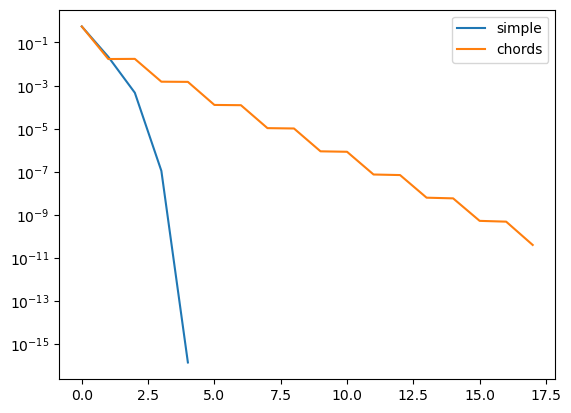

In [263]:
import sympy as sym
from numpy.linalg import norm
from itertools import takewhile
from sympy.utilities.lambdify import lambdify

sistema = [lambda x0, x1: x0**2+x0*x1-10, lambda x0, x1: x1+3*x0*x1**2-57] 
symbs = sym.symbols('x0, x1')

derivata_part = lambda func, symb: lambdify(symbs, sym.diff(func, symb, 1), np)
J = lambda sistema, symbs: np.array([[derivata_part(func(*symbs), symb) for symb in symbs] for func in sistema])

Jac = J(sistema, symbs)
x = np.arange(0, 4, 0.1)
X, Y = np.meshgrid(x, x)
[plt.contour(X, Y, func(X, Y), levels=0) for func in sistema]
plt.show()

def iterate(func, start):
    while True:
        yield start
        start = func(start)

def newton_raphson(f, J, x0, s, tolx=1e-10, tolf=1e-10, itmax=1000):
    err = lambda xk: norm(s(f, J, xk))/norm(xk)
    def stop_criteria (i, X):
        return i < itmax and err(X) > tolx and norm(f(X)) > tolf and lin.det(J(X)) != 0

    iter = iterate(lambda xk: xk + s(f,J, xk), (x0))
    arr = list(dict(takewhile(lambda param: stop_criteria(*param), enumerate(iter))).values()) + [next(iter)]

    err_arr = [err(x) for x in arr]
    return arr[-1], len(arr), err_arr


def newton_raphson_simple(f, J, x0):
    return newton_raphson(f, J, x0, lambda f, J, X: -lin.solve(J(X), f(X)))

def newton_raphson_chord(f, J, x0):
    return newton_raphson(f, J, x0, lambda f, J, X: -lin.solve(J(x0), f(X)))

x0 = (3, 1.5)
f = lambda X: [func(*X) for func in sistema]
Jacobian = lambda X: np.array([[fu(*X) for fu in v] for v in Jac])

def plot_method(method, name):
    sol, it, err = method(f, Jacobian, x0)
    print(f'soluzioni → {sol}')
    plt.semilogy(range(it), err, label=name)
    plt.legend()

plot_method(newton_raphson_simple, 'simple')
plot_method(newton_raphson_chord, 'chords')
